# Object-Oriented Programming for X-ray Diffraction Modeling
Very basic notebook demonstrating how to use OOP principles to model X-ray diffraction (XRD) patterns, starting with a basic structure and then progressing to calculations. This is not the 2D detector case but perhaps is illustrative?

In [1]:
# Step 1: Define Basic Classes
import numpy as np
import matplotlib.pyplot as plt

class Crystal:
    """Represents a crystalline material with a given lattice parameter."""
    def __init__(self, lattice_param, planes):
        self.lattice_param = lattice_param  # Lattice parameter in Ångströms
        self.planes = planes  # List of Miller indices

class XRaySource:
    """Represents an X-ray source with a specific wavelength."""
    def __init__(self, wavelength):
        self.wavelength = wavelength  # Wavelength in Ångströms


## Step 2: Implement Diffraction Calculations
Using Bragg's Law: $n lambda = 2d sin	theta$

In [2]:
class DiffractionExperiment:
    """Simulates an X-ray diffraction experiment."""
    def __init__(self, crystal, xray_source):
        self.crystal = crystal
        self.xray_source = xray_source

    def calculate_diffraction_angles(self):
        """Calculates 2θ angles for diffraction peaks."""
        theta_values = []
        for hkl in self.crystal.planes:
            d_hkl = self.crystal.lattice_param / np.sqrt(hkl[0]**2 + hkl[1]**2 + hkl[2]**2)
            theta = np.arcsin(self.xray_source.wavelength / (2 * d_hkl)) * (180 / np.pi)
            if not np.isnan(theta):
                theta_values.append(theta * 2)
        return theta_values


## Step 3: Run the Simulation and Plot Results

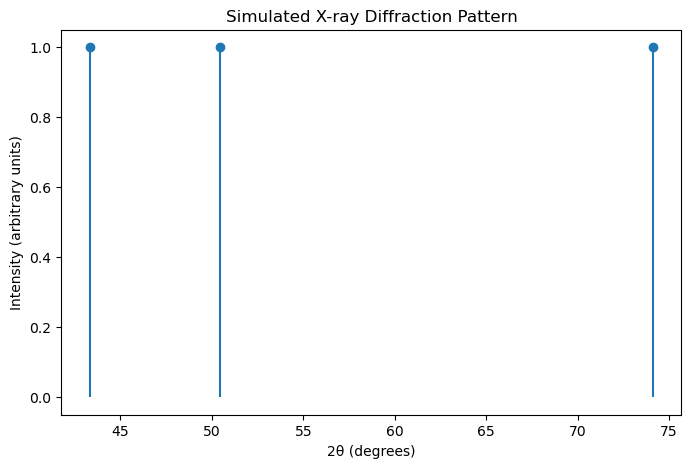

In [3]:
# Create a crystal with FCC structure and Miller indices (111), (200), (220)
fcc_crystal = Crystal(lattice_param=3.615, planes=[(1, 1, 1), (2, 0, 0), (2, 2, 0)])

# Use a Cu K-alpha X-ray source
xray_source = XRaySource(wavelength=1.5406)

# Run experiment
experiment = DiffractionExperiment(fcc_crystal, xray_source)
angles = experiment.calculate_diffraction_angles()

# Plot diffraction pattern
plt.figure(figsize=(8, 5))
plt.stem(angles, np.ones_like(angles), basefmt=' ')
plt.xlabel('2θ (degrees)')
plt.ylabel('Intensity (arbitrary units)')
plt.title('Simulated X-ray Diffraction Pattern')
plt.show()
